# 01 - Exploratory Data Analysis

**Crime Forecast LA** — Spatio-Temporal Crime Mining of LAPD records (2020–present).

Goal: understand the dataset shape, temporal/spatial/categorical structure, and missingness before any modelling.


In [1]:
# bootstrap: make src importable
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
from src import data_loader, eda
from src.utils import apply_plot_style
apply_plot_style()

df = data_loader.load_clean()
print('shape:', df.shape)
df.head(3)

02:07:18 | INFO    | src.data_loader | [start] load clean crimes_clean.parquet


02:07:18 | INFO    | src.data_loader | [done ] load clean crimes_clean.parquet in 0.41s


shape: (955339, 41)


,dr_no,date_reported,date_occurred,time_occurred,area_id,area_name,report_district,part_class,crime_code,crime_desc,...,year,week,is_weekend,report_lag_days,part_of_day,has_coords,is_violent,is_arrest,status_group,weapon_used
0,202010096,2020-05-24,2020-01-01,1340,20,Olympic,2022,1,440,THEFT PLAIN - PETTY ($950 & UNDER),...,2020,1,False,144,Afternoon,True,0,0,Investigation Continued,0
1,201514857,2020-09-05,2020-01-01,1200,15,N Hollywood,1545,2,354,THEFT OF IDENTITY,...,2020,1,False,248,Afternoon,True,0,0,Investigation Continued,0
2,200604051,2020-01-02,2020-01-01,2300,6,Hollywood,0668,1,210,ROBBERY,...,2020,1,False,1,Night,True,1,0,Investigation Continued,1


## Dataset overview

In [2]:
eda.overview(df)

,rows,columns,date_min,date_max,areas,crime_types,violent_share,arrest_share,missing_lat_pct
0,955339,41,2020-01-01,2024-06-24,21,139,0.167327,0.090556,0.00237


## Missing-value audit

In [3]:
eda.missing_table(df).head(20)

,missing_pct,missing_count
crime_code_4,0.999933,955275
crime_code_3,0.997599,953045
crime_code_2,0.928333,886873
cross_street,0.844139,806439
weapon_desc,0.659787,630320
weapon_code,0.659787,630320
victim_age,0.257220,245732
mo_codes,0.143064,136675
lat,0.002370,2264
lon,0.002370,2264


## Temporal pattern: crimes over time

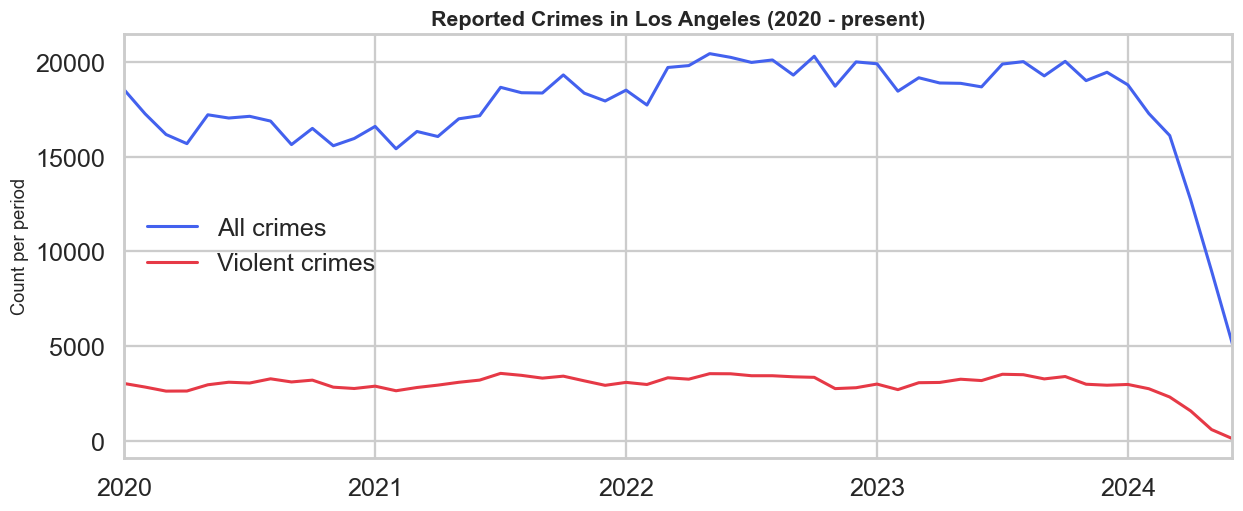

In [4]:
eda.plot_crimes_over_time(df);

**Observation:** monthly volume is fairly stable around ~20k/month with a clear decline starting in 2024 (partly real, partly LAPD reporting lag).


## Hour-of-day × Day-of-week

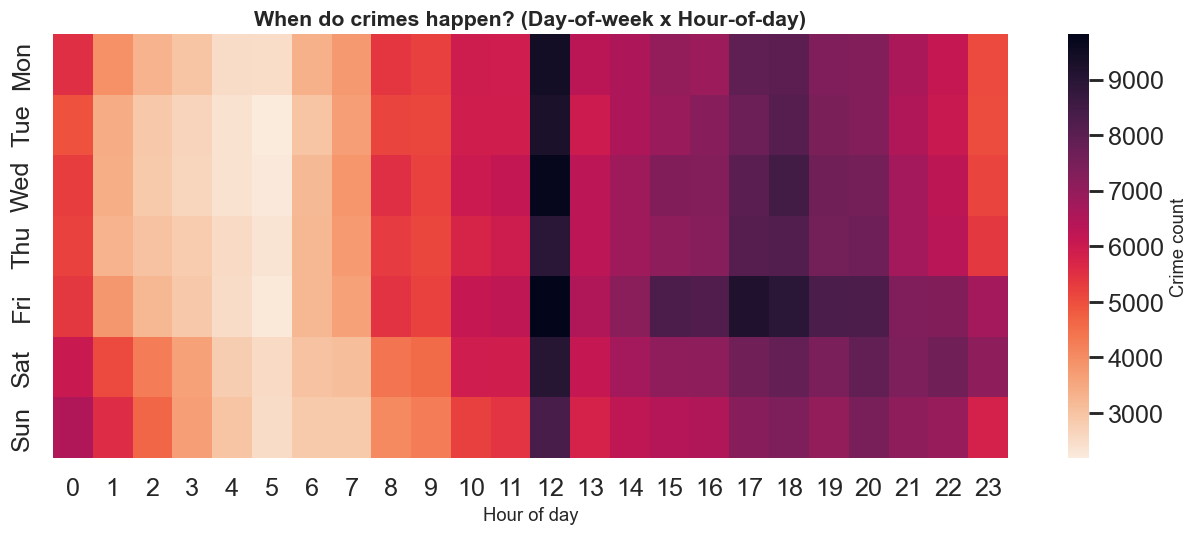

In [5]:
eda.plot_hour_dow_heatmap(df);

**Observation:** crime peaks in the **afternoon to evening** hours (16:00 – 22:00) across all days, with a noticeable Friday/Saturday late-night spike.


## Spatial: top LAPD areas

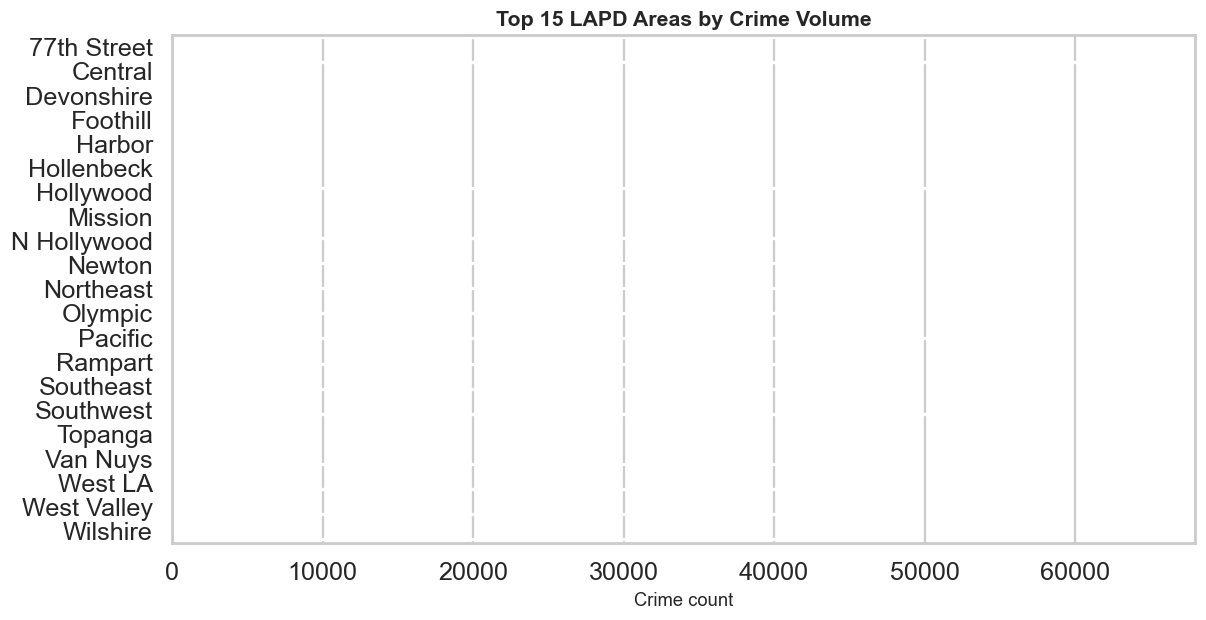

In [6]:
eda.plot_top_areas(df);

## Categorical: top crime types

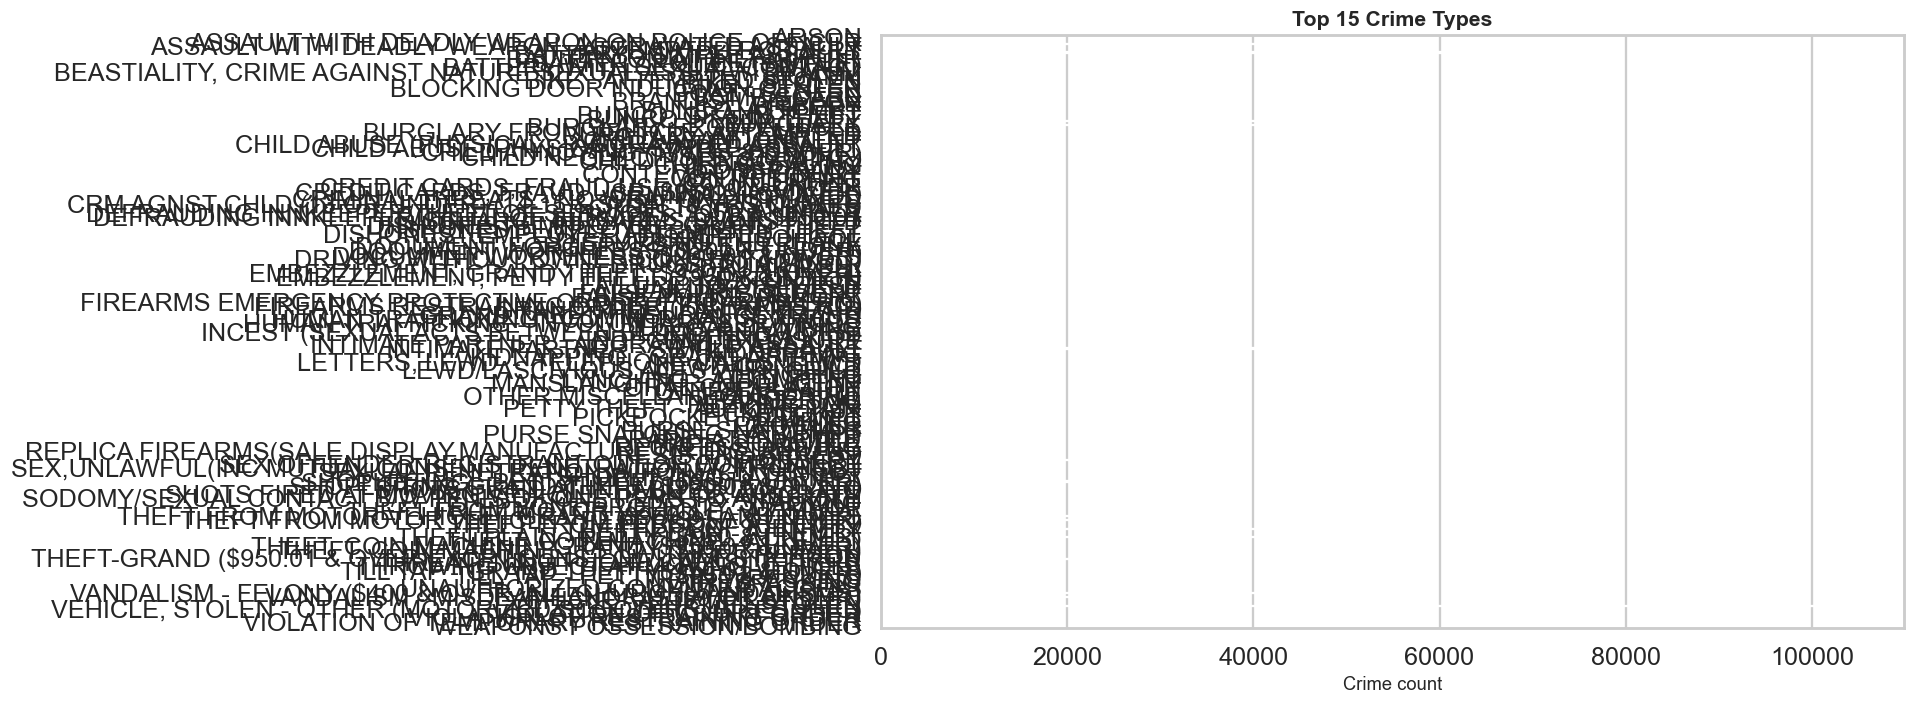

In [7]:
eda.plot_top_crime_types(df);

## Victim demographics

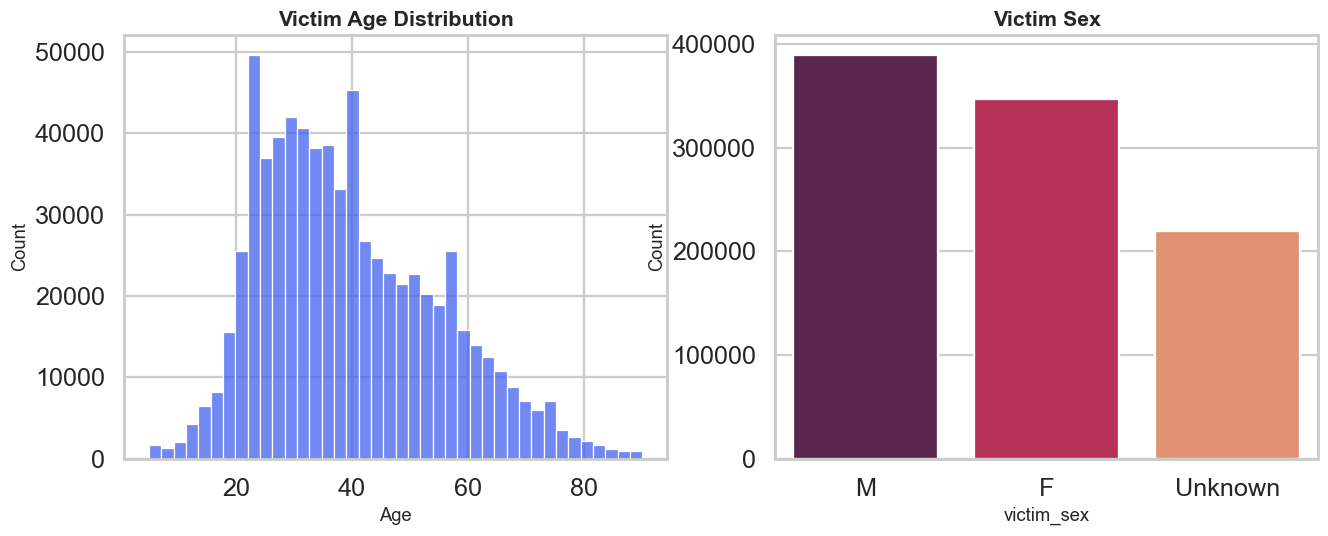

In [8]:
eda.plot_victim_demographics(df);

## Arrest rate by crime type

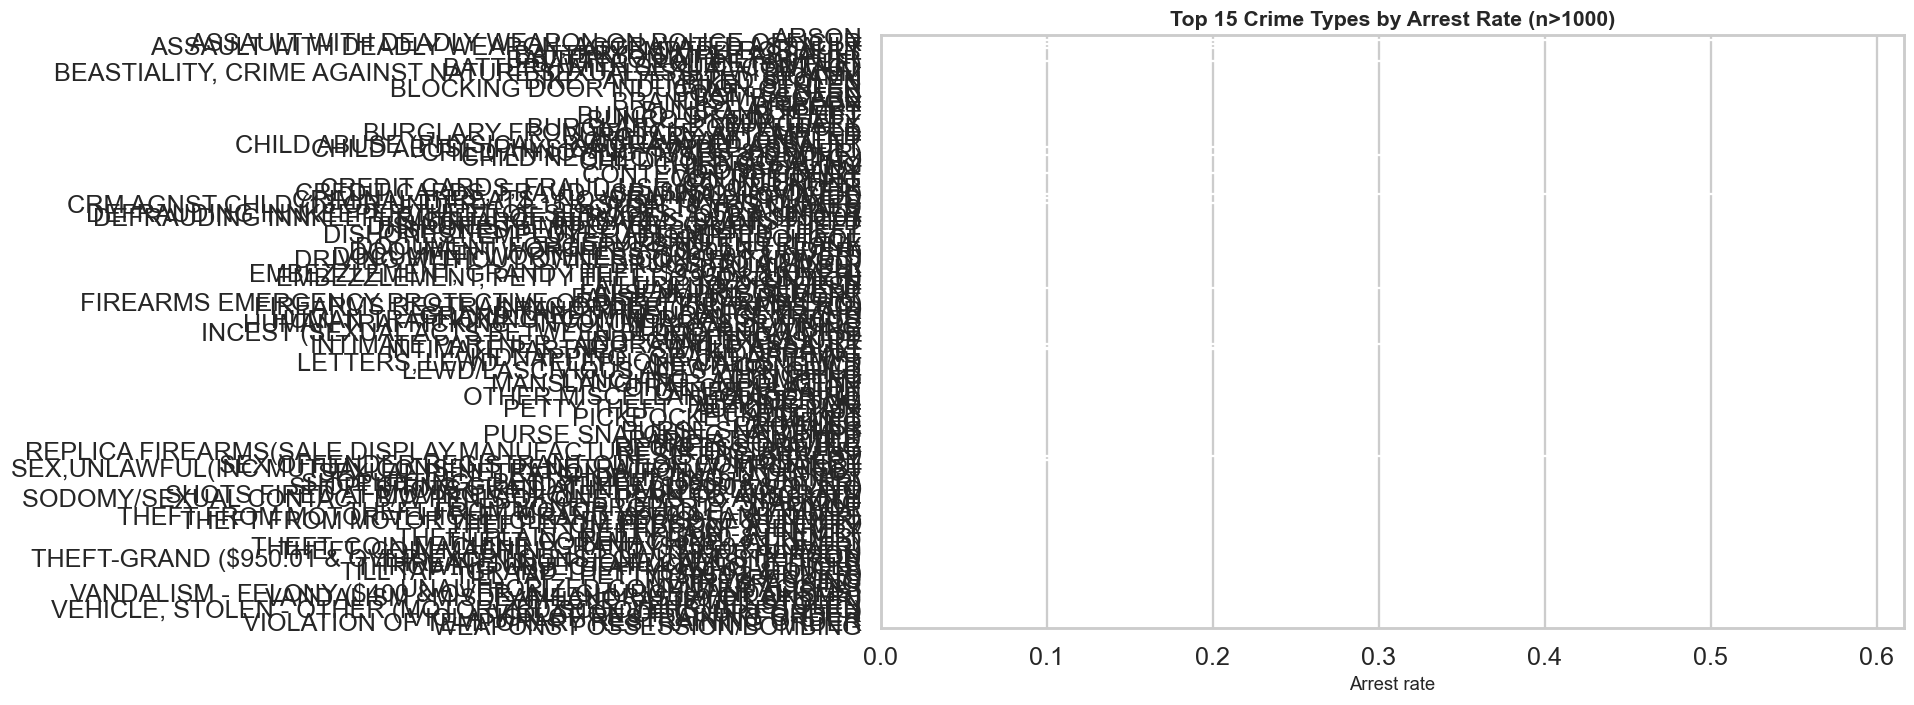

In [9]:
eda.plot_arrest_rate_by_crime(df);

## Violent share by area

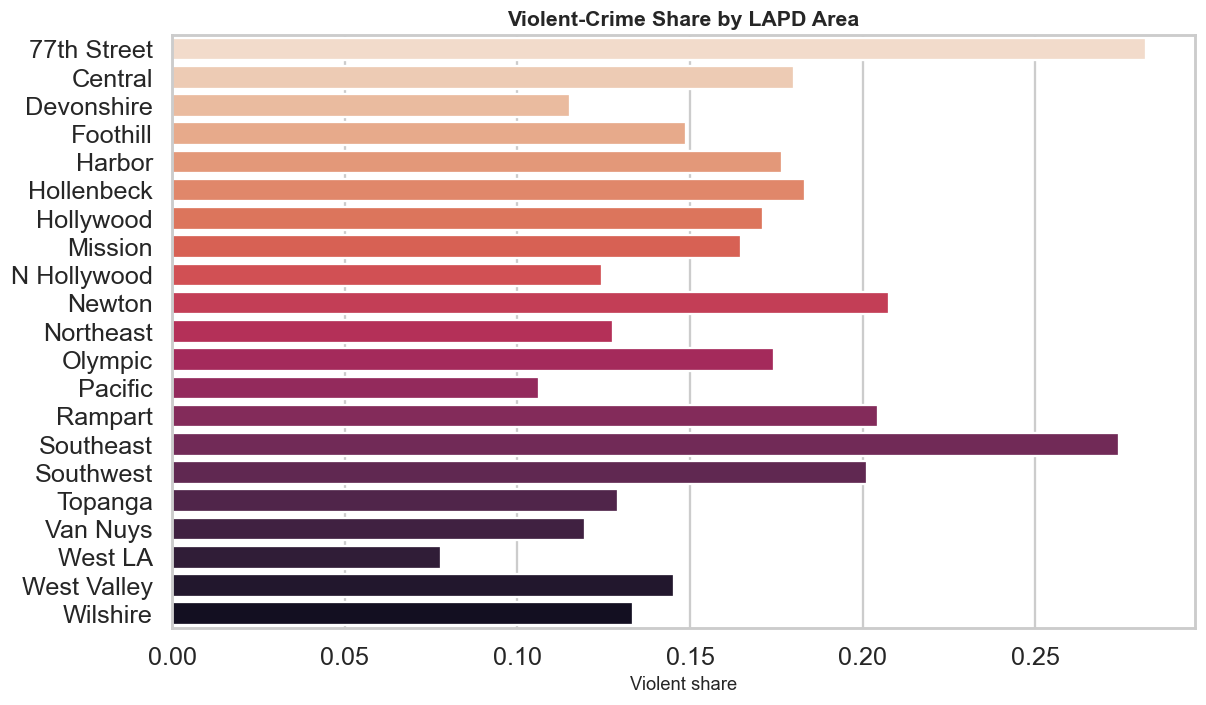

In [10]:
eda.plot_violent_share_by_area(df);

## Takeaways for the modelling pipeline

* Temporal seasonality is strong (hour-of-day + day-of-week) → cyclic encodings used.
* Heavy class imbalance for `is_arrest` (~9%) → needs `class_weight=balanced`.
* Some areas (77th, Southwest, Southeast) carry both high volume *and* high violent share.
* Recent months (2024+) under-report due to LAPD reporting lag → trim before forecasting.
